# 02 — Dos modelos: Softmax y Graph-MLP

Se corrige el error del prototipo original: `einsum('nn,bnf->bnf')` tomaba solo la diagonal nula de A. La implementación reproducible usa sumas de vecinos y la ecuación `H(t+1)=(1−α)H(t)+αD⁻¹AH(t)`.

In [1]:
from pathlib import Path
import sys, urllib.request
import numpy as np

SEED = 2026
rng = np.random.default_rng(SEED)

# Funciona desde notebooks/ en el repositorio y también en Colab.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "raw" / "mnist.npz"
SRC = ROOT / "src"
if not SRC.exists():
    # Si se subió solo el notebook, crea una ruta local y descarga los datos.
    ROOT = Path.cwd()
    DATA = ROOT / "mnist.npz"
if not DATA.exists():
    DATA.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz", DATA
    )
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

data = np.load(DATA)
x_train = data["x_train"].astype(np.float32) / 255.0
y_train = data["y_train"].astype(np.int64)
x_test = data["x_test"].astype(np.float32) / 255.0
y_test = data["y_test"].astype(np.int64)
print("Semilla:", SEED, "| entrenamiento:", x_train.shape, "| prueba:", x_test.shape)

Semilla: 2026 | entrenamiento: (60000, 28, 28) | prueba: (10000, 28, 28)


In [2]:
from modelado_mnist import (
    GraphMLP, SoftmaxRegression, graph_message_features, raw_features,
    stratified_indices, stratified_split, classification_metrics
)

raw_train, raw_test = raw_features(x_train), raw_features(x_test)
graph_train = graph_message_features(x_train, alpha=0.35, steps=2)
graph_test = graph_message_features(x_test, alpha=0.35, steps=2)
idx = stratified_indices(y_train, 30000, seed=SEED)
tr, va = stratified_split(y_train[idx], val_fraction=0.15, seed=SEED)
print(raw_train.shape, graph_train.shape)

(60000, 784) (60000, 784)


## Modelo 1 — Regresión Softmax

`P(y=k|x)=exp(w_kᵀx+b_k)/Σ_j exp(w_jᵀx+b_j)`. Es un límite inferior interpretable: separa clases mediante fronteras lineales.

In [3]:
softmax = SoftmaxRegression(784, l2=1e-4, seed=SEED)
hist_softmax = softmax.fit(raw_train[idx][tr], y_train[idx][tr], raw_train[idx][va], y_train[idx][va], epochs=12, seed=SEED)
m_softmax = classification_metrics(y_test, softmax.predict_proba(raw_test))
{k: round(v, 4) for k, v in m_softmax.items() if k != "confusion_matrix"}

{'accuracy': 0.923,
 'precision_macro': 0.9219,
 'recall_macro': 0.9222,
 'f1_macro': 0.9219,
 'log_loss': 0.2797}

## Modelo 2 — Graph-MLP

Primero propaga intensidad por el grafo de 8 vecinos durante dos pasos; después aplica una capa ReLU de 64 unidades y una salida Softmax. Combina el supuesto de localidad espacial con una frontera no lineal.

In [4]:
graph_mlp = GraphMLP(784, hidden=64, l2=1e-4, seed=SEED)
hist_graph = graph_mlp.fit(graph_train[idx][tr], y_train[idx][tr], graph_train[idx][va], y_train[idx][va], epochs=12, seed=SEED)
m_graph = classification_metrics(y_test, graph_mlp.predict_proba(graph_test))
{k: round(v, 4) for k, v in m_graph.items() if k != "confusion_matrix"}

{'accuracy': 0.9556,
 'precision_macro': 0.9552,
 'recall_macro': 0.9552,
 'f1_macro': 0.9551,
 'log_loss': 0.1519}

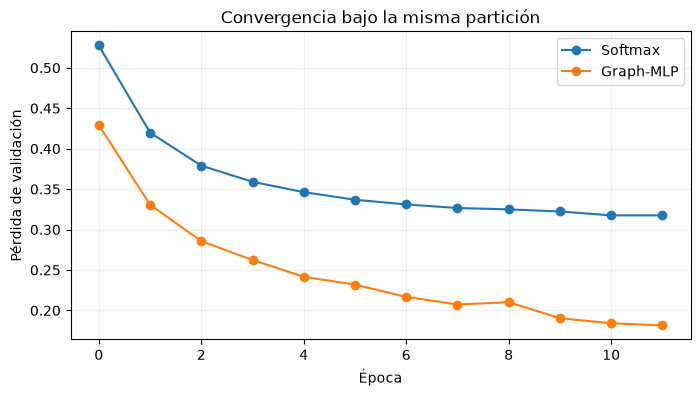

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(hist_softmax.val_loss, marker="o", label="Softmax")
plt.plot(hist_graph.val_loss, marker="o", label="Graph-MLP")
plt.xlabel("Época"); plt.ylabel("Pérdida de validación"); plt.legend(); plt.grid(alpha=.2)
plt.title("Convergencia bajo la misma partición")
plt.show()

## Resultado esperado

Softmax: exactitud ≈ 0.923 y F1 macro ≈ 0.922. Graph-MLP: exactitud ≈ 0.956 y F1 macro ≈ 0.955. Pequeñas variaciones pueden aparecer por la implementación BLAS, pero la semilla y las particiones permanecen fijas.